# Учимся работе с данными - от загрузки до моделирования

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, roc_auc_score

from sklearn.metrics import precision_score, recall_score, f1_score

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('data.csv')

if 'id' in df.columns:
    df = df.drop('id', axis=1)

print(f"\nРазмер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")


Размер данных: 569 строк, 32 столбцов


In [5]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [12]:
df = df.dropna(axis=1, how='all')

In [13]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [15]:
# Конвертируем диагноз в числа для анализа
df_diagnosis = df.copy()
df_diagnosis['diagnosis'] = df_diagnosis['diagnosis'].map({'M': 1, 'B': 0})

# Базовые статистики
print(df_diagnosis.describe())

        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720       

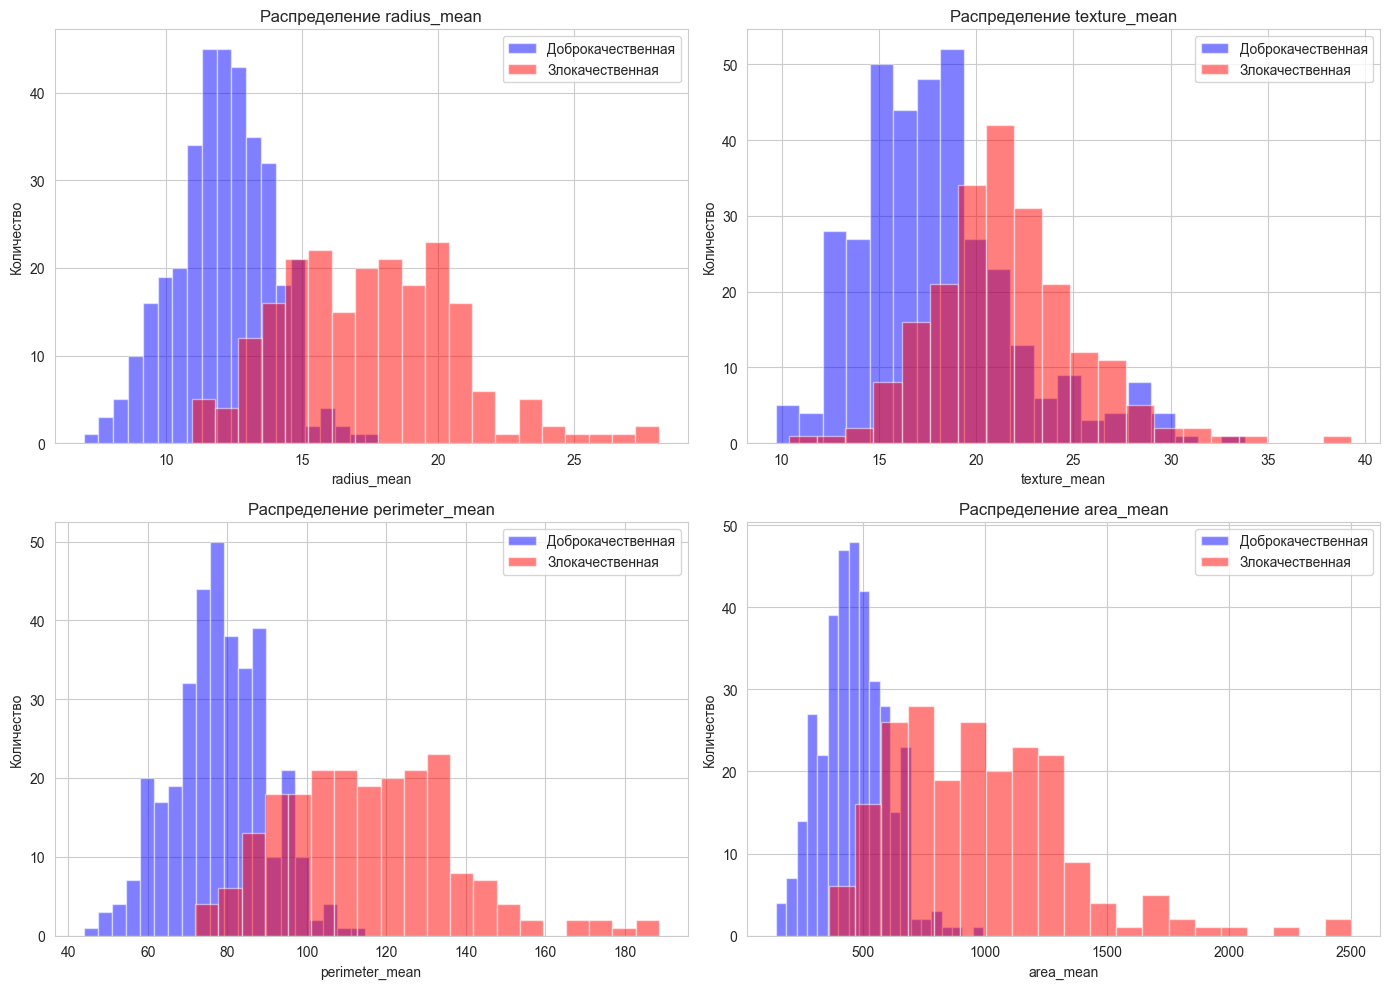

In [18]:
# Создадим копию с диагнозом в читаемом формате для графиков
df_plot = df.copy()

# Посмотрим на распределения нескольких ключевых признаков
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

# Создаем 4 графика
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(features_to_plot):
    # Разделяем данные по диагнозу
    for diagnosis, color, label in zip(['B', 'M'], ['blue', 'red'], ['Доброкачественная', 'Злокачественная']):
        subset = df_plot[df_plot['diagnosis'] == diagnosis]
        axes[i].hist(subset[feature], bins=20, alpha=0.5, color=color, label=label)
        axes[i].set_title(f'Распределение {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Количество')
        axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
#Вывод:
#Злокачественные опухоли имеют большие размеры - радиус, периметр, площадь. По этим признакам легко отличать рак от доброкачественных образований.

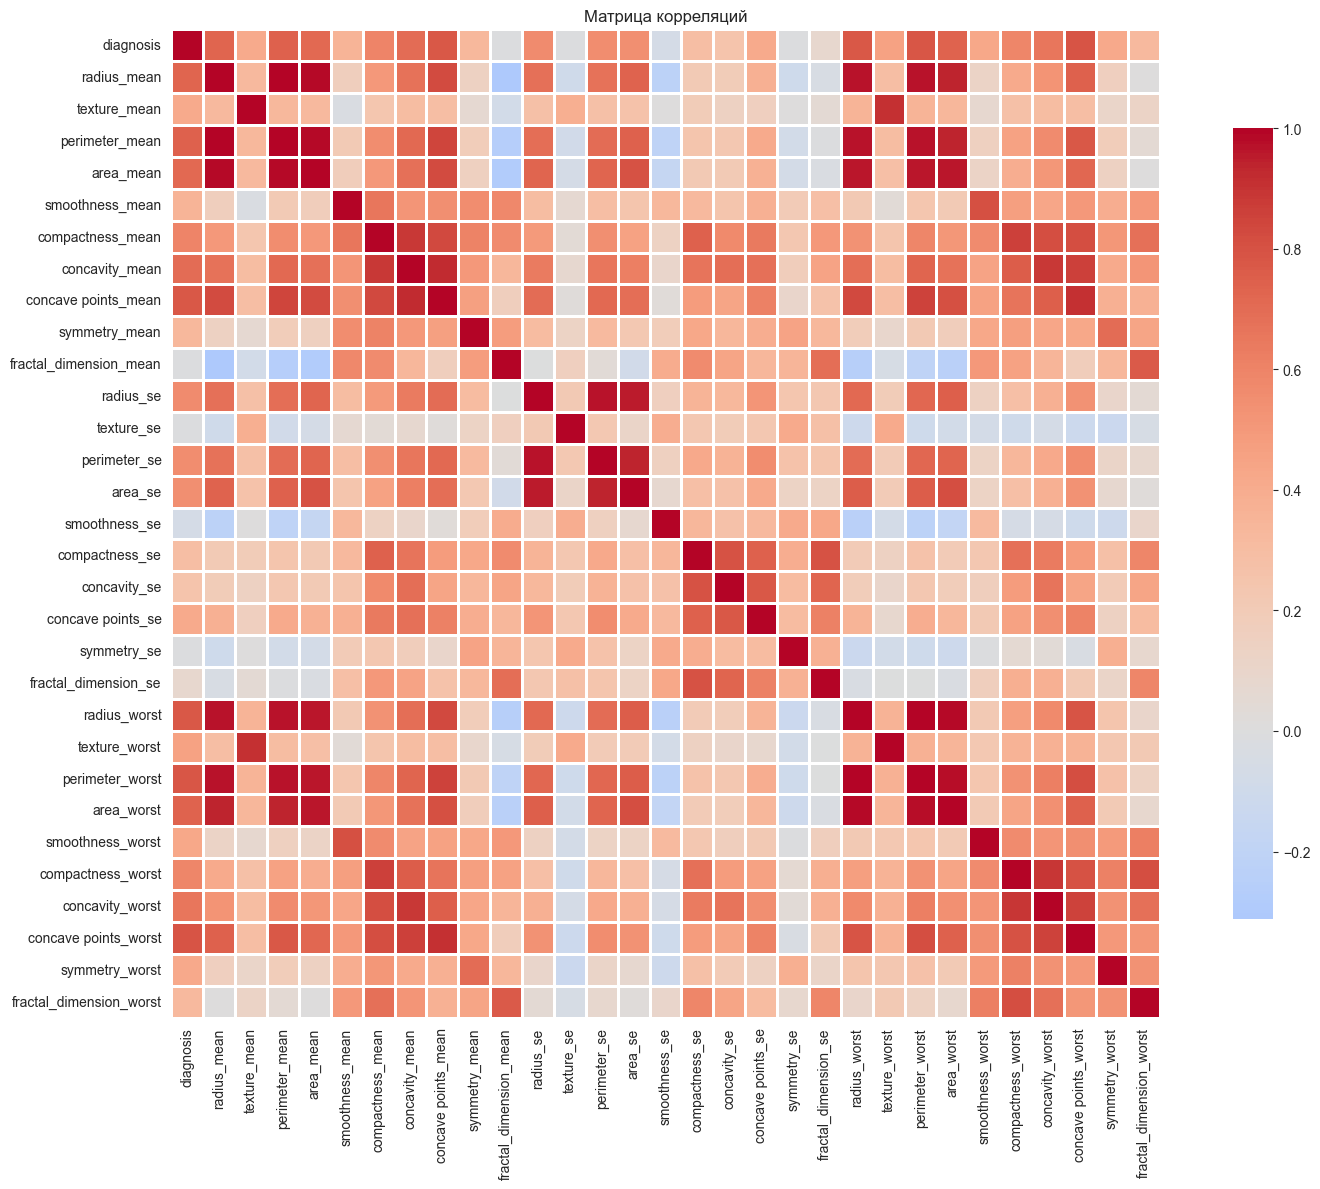

Самые сильные положительные корреляции:
radius_mean      perimeter_mean     0.997855
perimeter_mean   radius_mean        0.997855
radius_worst     perimeter_worst    0.993708
perimeter_worst  radius_worst       0.993708
radius_mean      area_mean          0.987357
dtype: float64
Самые сильные отрицательные корреляции:
fractal_dimension_mean  radius_mean              -0.311631
radius_mean             fractal_dimension_mean   -0.311631
area_mean               fractal_dimension_mean   -0.283110
fractal_dimension_mean  area_mean                -0.283110
                        perimeter_mean           -0.261477
dtype: float64


In [27]:
# Создаем матрицу корреляций
corr_matrix = df_diagnosis.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # убираем корреляцию с самим собой
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

print("Самые сильные положительные корреляции:")
print(corr_pairs.sort_values(ascending=False).head(5))

print("Самые сильные отрицательные корреляции:")
print(corr_pairs.sort_values().head(5))

In [ ]:
# Многие признаки дублируют друг друга, например, radius_mean, perimeter_mean и area_mean - говорят практически об одном и том же, о размере

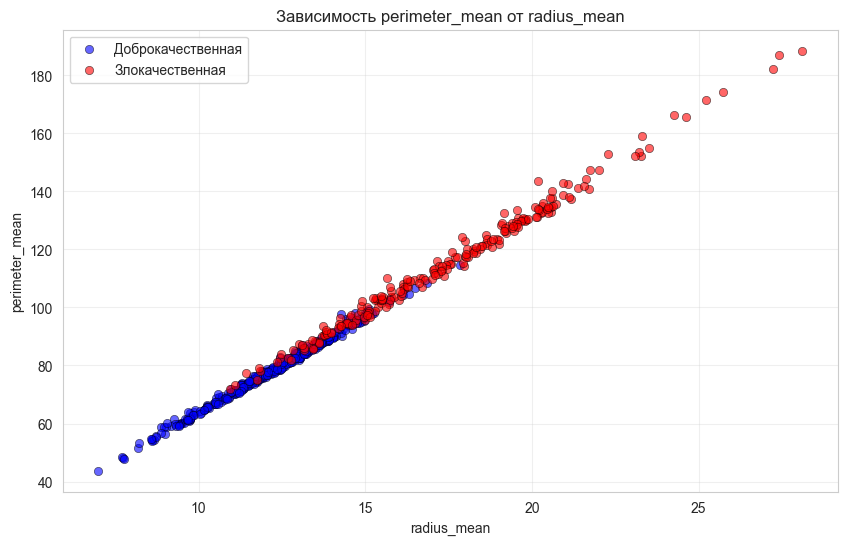

In [19]:
# Возьмем самую коррелированную пару
feature1 = 'radius_mean'
feature2 = 'perimeter_mean'

plt.figure(figsize=(10, 6))
for diagnosis, color, label in zip(['B', 'M'], ['blue', 'red'], ['Доброкачественная', 'Злокачественная']):
    subset = df_plot[df_plot['diagnosis'] == diagnosis]
    plt.scatter(subset[feature1], subset[feature2], 
                c=color, label=label, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f'Зависимость {feature2} от {feature1}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Вывод: корреляция 0.998 - это почти линейная зависимость. Если знать радиус, можно с высокой точностью предсказать периметр.

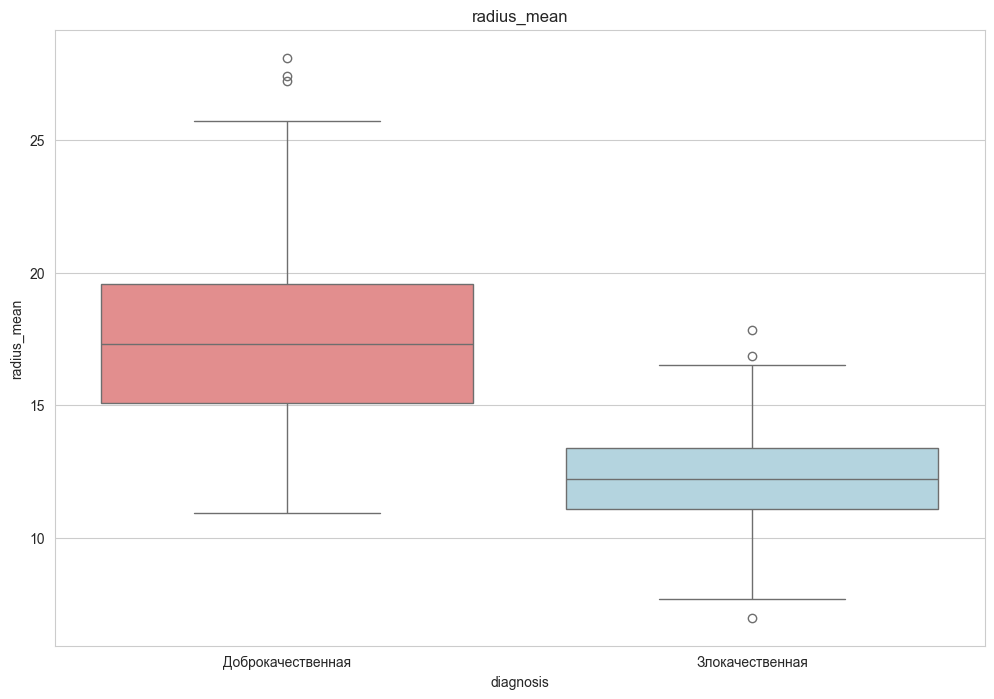

In [23]:
sns.boxplot(data=df_plot, 
            x='diagnosis', 
            y='radius_mean', 
            hue='diagnosis', 
            palette={'B': 'lightblue', 'M': 'lightcoral'},
            legend=False)    

plt.xticks(ticks=[0, 1], labels=['Доброкачественная', 'Злокачественная'])
plt.title('radius_mean')
plt.show()

In [ ]:
# Вывод: Ящики почти не перекрываются, что оч хорошо. Если radius_mean < 14 - скорее всего доброкачественная, если > 16 - злокачественная. radius_mean - отличный признак для разделения классов

In [30]:
df = pd.read_csv('data.csv')

df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f"Данные: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Доброкач.: {sum(df['diagnosis']==0)}, Злокач.: {sum(df['diagnosis']==1)}")

Данные: 569 строк, 31 столбцов
Доброкач.: 357, Злокач.: 212


In [31]:
# X - все признаки, y - диагноз
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (398, 30)
Тестовая выборка: (171, 30)


In [42]:
# Создаем и применяем стандартизацию
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"До стандартизации", pd.DataFrame(X_train.iloc[:5, :5]).round(2))
print(f"После стандартизации", pd.DataFrame(X_train_scaled[:5, :5]).round(2))

До стандартизации      radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean
78         20.18         23.97          143.70     1245.0             0.13
330        16.03         15.51          105.80      793.2             0.09
378        13.66         15.15           88.27      580.6             0.08
213        17.42         25.56          114.50      948.0             0.10
89         14.64         15.24           95.77      651.9             0.11
После стандартизации       0     1     2     3     4
0  1.71  1.05  2.12  1.67  2.28
1  0.54 -0.91  0.57  0.39 -0.07
2 -0.13 -0.99 -0.15 -0.21 -0.92
3  0.93  1.42  0.93  0.83  0.33
4  0.14 -0.97  0.16 -0.01  1.21


In [43]:
# Создаем и обучаем модель
knn_default = KNeighborsClassifier()
knn_default.fit(X_train_scaled, y_train)

# Предсказания
y_pred = knn_default.predict(X_test_scaled)
y_proba = knn_default.predict_proba(X_test_scaled)[:, 1]

# Метрики
print("МЕТРИКИ КАЧЕСТВА:")
print(classification_report(y_test, y_pred, target_names=['Доброкач.', 'Злокач.']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(f"[[{cm[0,0]}  {cm[0,1]}]\n [{cm[1,0]}  {cm[1,1]}]]")

МЕТРИКИ КАЧЕСТВА:
              precision    recall  f1-score   support

   Доброкач.       0.95      1.00      0.97       107
     Злокач.       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171

Матрица ошибок:
[[107  0]
 [6  58]]


In [ ]:
# Модель пропустила 6 злокачественных, сказав что они доброкачественные. Модель не ошиблась, сказав "злокачественная" на доброкачественной

In [51]:
# Создаем модель kNN с параметрами по умолчанию (n_neighbors=5)
knn_default = KNeighborsClassifier()

# Обучаем модель на стандартизованных данных
knn_default.fit(X_train_scaled, y_train)

# Делаем предсказания на тестовых данных
y_pred_default = knn_default.predict(X_test_scaled)

# Получаем вероятности для ROC-кривой
y_proba_default = knn_default.predict_proba(X_test_scaled)[:, 1]  # вероятность класса 1 (злокач.)

print("МОДЕЛЬ kNN С ПАРАМЕТРАМИ ПО УМОЛЧАНИЮ (k=5)")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_default)
print("МАТРИЦА ОШИБОК:")
print("                 Предсказано")
print("               Доброкач.  Злокач.")
print(f"Реально Доброкач.   {cm[0,0]:3d}       {cm[0,1]:3d}")
print(f"        Злокач.     {cm[1,0]:3d}       {cm[1,1]:3d}")

# Детальный отчет по метрикам
print("МЕТРИКИ КАЧЕСТВА:")
print(classification_report(y_test, y_pred_default, 
                           target_names=['Доброкачественная', 'Злокачественная']))


accuracy = accuracy_score(y_test, y_pred_default)
precision = precision_score(y_test, y_pred_default)
recall = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)
roc_auc = roc_auc_score(y_test, y_proba_default)
print(f"Accuracy (Точность): {accuracy:.3f}")
print(f"Precision (Точность предсказания): {precision:.3f}")
print(f"Recall (Полнота): {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

МОДЕЛЬ kNN С ПАРАМЕТРАМИ ПО УМОЛЧАНИЮ (k=5)
МАТРИЦА ОШИБОК:
                 Предсказано
               Доброкач.  Злокач.
Реально Доброкач.   107         0
        Злокач.       6        58
МЕТРИКИ КАЧЕСТВА:
                   precision    recall  f1-score   support

Доброкачественная       0.95      1.00      0.97       107
  Злокачественная       1.00      0.91      0.95        64

         accuracy                           0.96       171
        macro avg       0.97      0.95      0.96       171
     weighted avg       0.97      0.96      0.96       171

Accuracy (Точность): 0.965
Precision (Точность предсказания): 1.000
Recall (Полнота): 0.906
F1-score: 0.951
ROC-AUC: 0.988


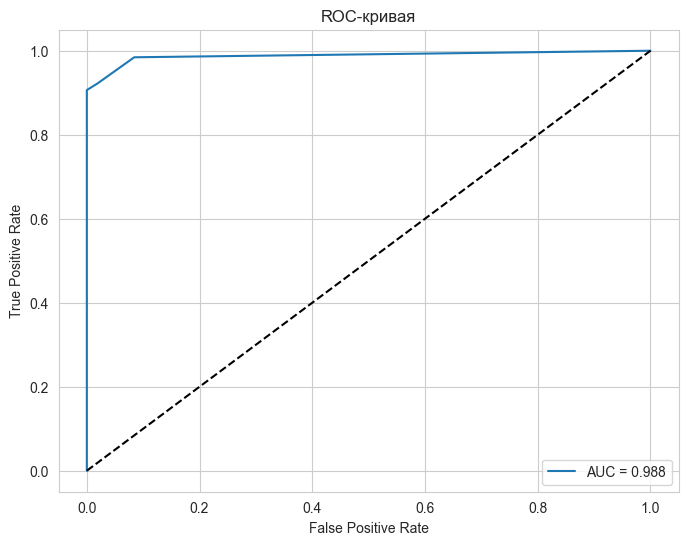

In [35]:
# Строим ROC-кривую
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

Лучшее k: 5
Лучшая точность на CV: 0.9697


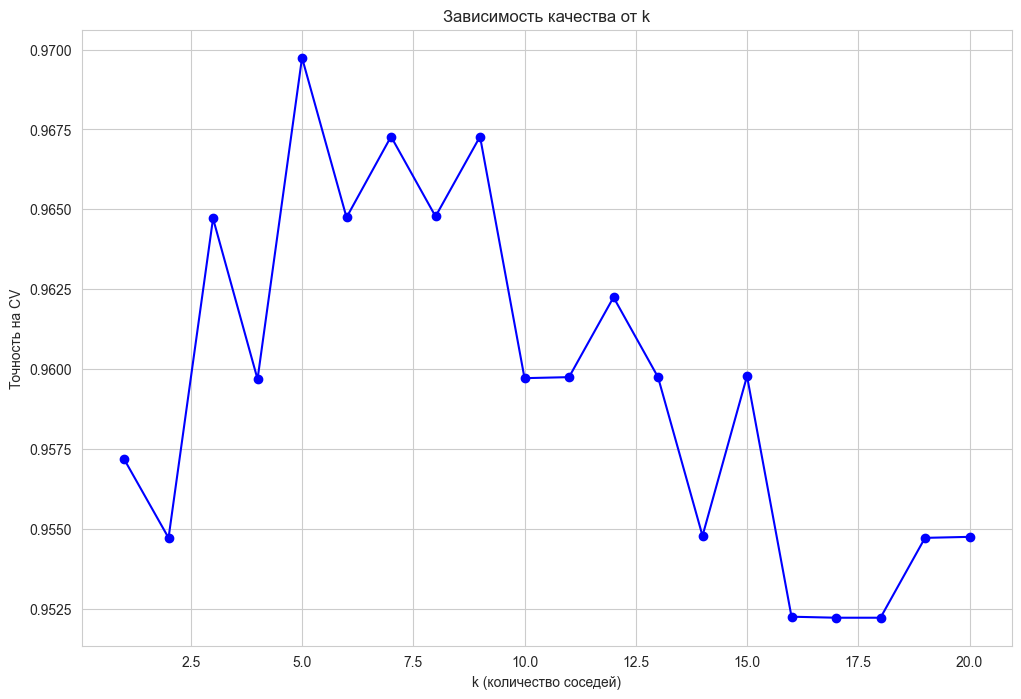

In [36]:
# Перебираем разные k 
param_grid = {'n_neighbors': range(1, 21)}

# GridSearch с 5-кратной кросс-валидацией
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print(f"Лучшее k: {grid.best_params_['n_neighbors']}")
print(f"Лучшая точность на CV: {grid.best_score_:.4f}") 

results = pd.DataFrame(grid.cv_results_)
plt.plot(range(1, 21), results['mean_test_score'], 'bo-')
plt.xlabel('k (количество соседей)')
plt.ylabel('Точность на CV')
plt.title('Зависимость качества от k')
plt.grid(True)
plt.show()

In [37]:
# Обучаем модель с лучшим k
knn_best = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
knn_best.fit(X_train_scaled, y_train)

# Предсказания
y_pred_best = knn_best.predict(X_test_scaled)
y_proba_best = knn_best.predict_proba(X_test_scaled)[:, 1]

# Сравнение с моделью по умолчанию
from sklearn.metrics import accuracy_score

acc_default = accuracy_score(y_test, y_pred)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Точность модели по умолчанию (k=5): {acc_default:.4f}")
print(f"Точность лучшей модели (k={grid.best_params_['n_neighbors']}): {acc_best:.4f}")
print(f"Изменение: {acc_best - acc_default:+.4f}")

Точность модели по умолчанию (k=5): 0.9649
Точность лучшей модели (k=5): 0.9649
Изменение: +0.0000


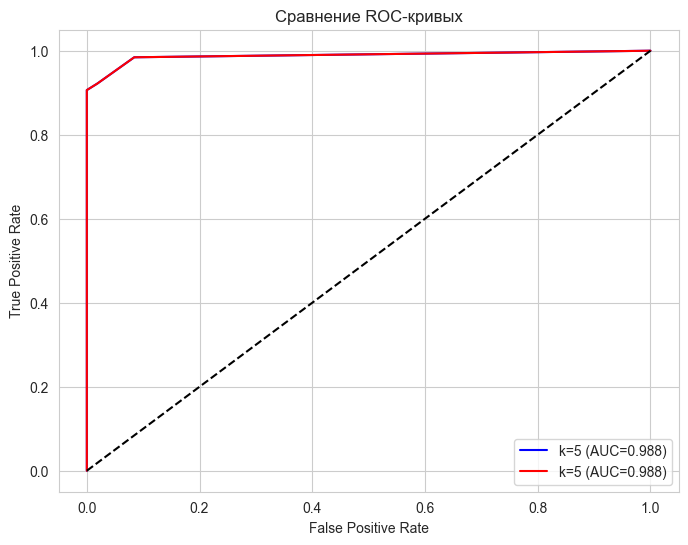

In [52]:
# ROC для лучшей модели
fpr_best, tpr_best, _ = roc_curve(y_test, y_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', label=f'k=5 (AUC={roc_auc:.3f})')
plt.plot(fpr_best, tpr_best, 'r-', label=f'k={grid.best_params_["n_neighbors"]} (AUC={roc_auc_best:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых')
plt.legend()
plt.show()

In [ ]:
# Выводы: нет ложных предсказаний. Высокая точность модели. Идеальный ROC-AUC. Данные в представленном датафрейме качественные и информативные